# Proyek Klasifikasi Gambar: Plant Village
- **Nama:** Ariella Asti Cahyani
- **Email:** ariellaasticahyani@gmail.com
- **ID Dicoding:** ariellaastch
  

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install split-folders
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.21.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ray 2.53.0 requires packaging>=24.2, but you have packaging 23.2 which is incompatible.
build 1.4.0 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==

In [2]:
import pandas as pd
import numpy as np
import os
import shutil
import splitfolders
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
import requests
from io import BytesIO

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

def set_seed(seed=99):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(99)

2026-02-28 22:01:44.849097: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772316105.038619      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772316105.092789      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772316105.546855      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772316105.546897      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772316105.546899      55 computation_placer.cc:177] computation placer alr

## Data Preparation

### Data Loading

In [3]:
input_dir = "/kaggle/input/datasets/mostafaabla/garbage-classification/garbage_classification"
print(f"Isi folder input: {os.listdir(input_dir)}")

Isi folder input: ['metal', 'white-glass', 'biological', 'paper', 'brown-glass', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic', 'green-glass']


In [4]:
print("\n--- Check Resolution ---")
sample_classes = os.listdir(input_dir)[:2]

for cls in sample_classes:
    cls_path = os.path.join(input_dir, cls)
    print(f"\nClass: {cls}")
    
    images = [f for f in os.listdir(cls_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]
    
    for img_name in images:
        img_path = os.path.join(cls_path, img_name)
        with Image.open(img_path) as img:
            width, height = img.size
            print(f"- ({width}, {height})")
print("------------------------------------------\n")


--- Check Resolution ---

Class: metal
- (512, 384)
- (225, 225)
- (512, 384)
- (306, 164)

Class: white-glass
- (259, 194)
- (512, 384)
- (225, 225)
- (237, 213)
------------------------------------------



In [5]:
dataset_final = "/kaggle/working/garbage_final"

splitfolders.ratio(input_dir, output=dataset_final, seed=82, ratio=(.8, .1, .1))

Copying files: 15515 files [00:53, 290.95 files/s]


In [6]:
path = dataset_final
if os.path.exists(path):
    print("Folder EXIST!")
    print(f"Isi folder final: {os.listdir(path)}")
else:
    print("Folder NOT EXIST")

Folder EXIST!
Isi folder final: ['test', 'val', 'train']


In [7]:
# Dataset Checking
def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        total += len(os.listdir(cls_path))
    return total

train_dir = os.path.join(dataset_final, "train")
val_dir   = os.path.join(dataset_final, "val")
test_dir  = os.path.join(dataset_final, "test")

print("Jumlah train:", count_images(train_dir))
print("Jumlah val:", count_images(val_dir))
print("Jumlah test:", count_images(test_dir))

Jumlah train: 12409
Jumlah val: 1545
Jumlah test: 1561


In [8]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=82
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False 
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Total Kelas: {num_classes}")

class_names = train_ds.class_names 
num_classes = len(class_names)

Found 12409 files belonging to 12 classes.


I0000 00:00:1772316182.743245      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 1545 files belonging to 12 classes.
Found 1561 files belonging to 12 classes.
Total Kelas: 12


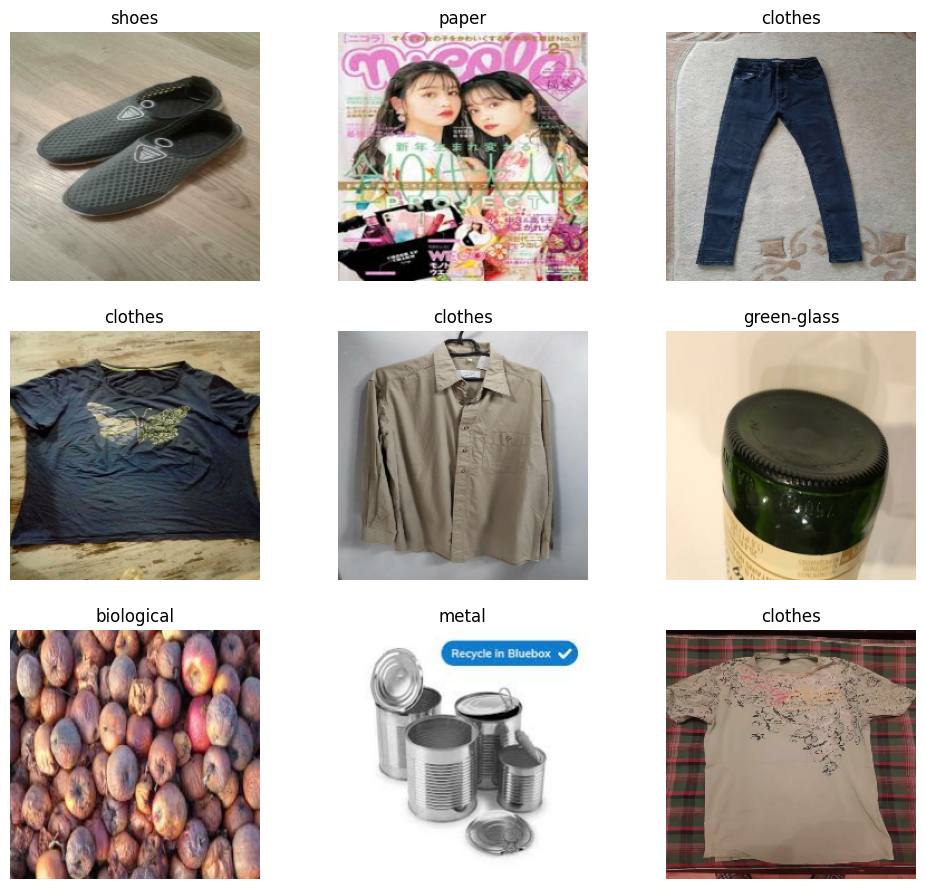

In [9]:
plt.figure(figsize=(12, 11))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

### Data Preprocessing

In [10]:
normalize_layer = layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)
])


AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

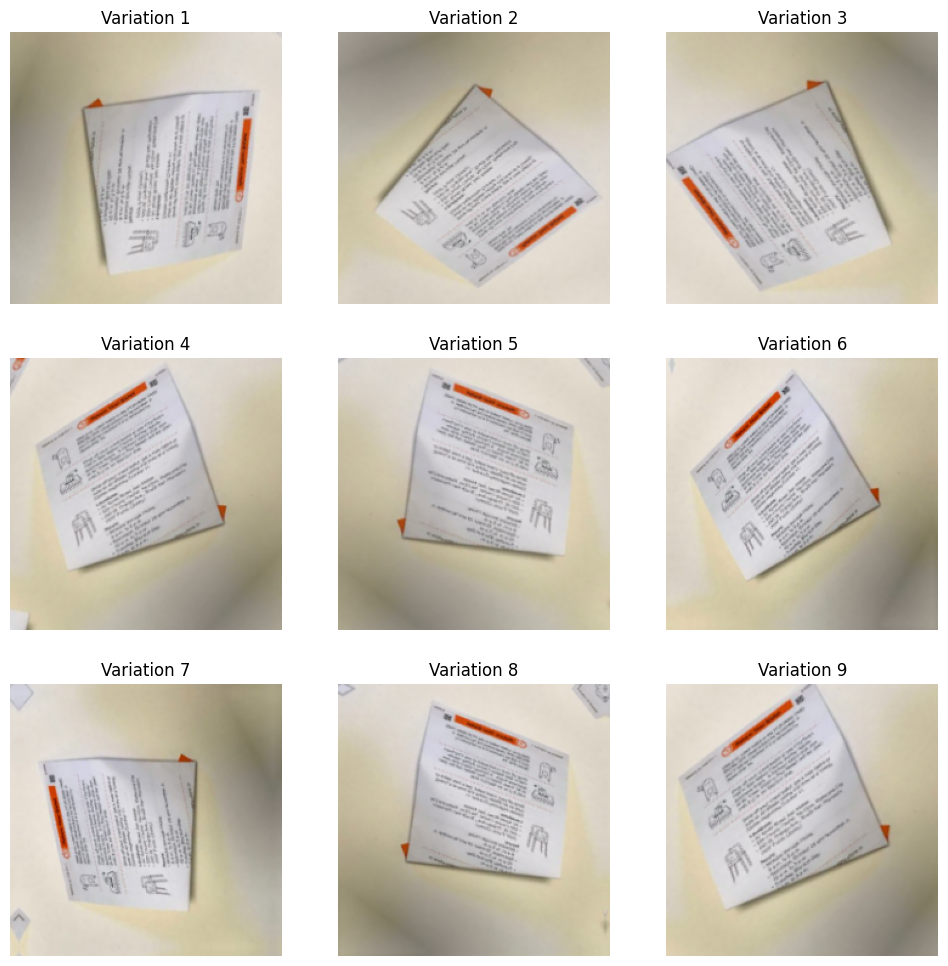

In [11]:
for images, labels in train_ds.take(1):
    first_image = images[0]
    
    plt.figure(figsize=(12, 12))
    for i in range(9):
        augmented_img = data_augmentation(tf.expand_dims(first_image, 0), training=True)
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_img[0].numpy().astype("uint8"))
        plt.title(f"Variation {i+1}")
        plt.axis("off")

## Modelling

In [12]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True 

for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(preprocess_input), 
    
    base_model,
    
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4), 
    layers.Dense(num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy']
             )

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,276,236 (20.13 MB)

 Trainable params: 4,224,332 (16.11 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [14]:
reduce_lr = ReduceLROnPlateau(
        monitor='val_accuracy', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-7,
        verbose=1
    ),

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    min_delta=0.001,
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

checkpoint_cb = ModelCheckpoint(
    filepath='best_model.weights.h5', 
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

In [15]:
epochs = 80

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds, 
    callbacks=[reduce_lr, early_stopping, checkpoint_cb]
)

Epoch 1/80


I0000 00:00:1772316215.209016     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7124 - loss: 1.0101
Epoch 1: val_accuracy improved from -inf to 0.90680, saving model to best_model.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.7127 - loss: 1.0091 - val_accuracy: 0.9068 - val_loss: 0.3149 - learning_rate: 1.0000e-04
Epoch 2/80
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9088 - loss: 0.2831
Epoch 2: val_accuracy improved from 0.90680 to 0.91197, saving model to best_model.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.9088 - loss: 0.2831 - val_accuracy: 0.9120 - val_loss: 0.2818 - learning_rate: 1.0000e-04
Epoch 3/80
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9294 - loss: 0.2356
Epoch 3: val_accuracy improved from 0.91197 to 0.93204, saving model to best_model.weights.h5
388/388 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.9294 - loss: 0.2356 - val_accuracy: 0.9320 - val_loss: 0.2639 - learning_rate: 1.0000e-04
Epoch 4/80
388/388 ━━━━━━━━━━━

In [16]:
best_epoch_loss = np.argmin(history.history['val_loss'])
val_loss_min = history.history['val_loss'][best_epoch_loss]
best_epoch_acc = np.argmax(history.history['val_accuracy'])
val_acc_max = history.history['val_accuracy'][best_epoch_acc]

print("============ SUMMARY ============")
print(f"Best Epoch                   : {best_epoch_acc}")
print(f"Best Validation Loss         : {val_loss_min:.4f}")
print(f"Best Validation Accuracy     : {val_acc_max * 100:.2f}%")

============ SUMMARY ============
Best Epoch                   : 14
Best Validation Loss         : 0.1828
Best Validation Accuracy     : 95.66%


## Evaluasi dan Visualisasi

In [17]:
loss, accuracy = model.evaluate(test_ds)
print(f"Final Loss: {loss:.4f}")
print(f"Final Accuracy: {accuracy * 100:.2f}%")


y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

predictions = model.predict(test_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=class_names))

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9713 - loss: 0.1365
Final Loss: 0.2082
Final Accuracy: 95.84%
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     battery       0.94      0.96      0.95        95
  biological       1.00      0.98      0.99        99
 brown-glass       0.87      0.97      0.92        62
   cardboard       0.94      0.98      0.96        90
     clothes       0.99      0.99      0.99       533
 green-glass       0.97      0.97      0.97        64
       metal       0.95      0.91      0.93        78
       paper       0.93      0.94      0.94       105
     plastic       0.93      0.82      0.87        87
       shoes       0.96      0.97      0.96       199
       trash       0.97      0.93      0.95        71
 white-glass       0.86      0.92      0.89        78

    accuracy                           0.96      1561
   macro avg       0.94      0.94      0.94      1561
w

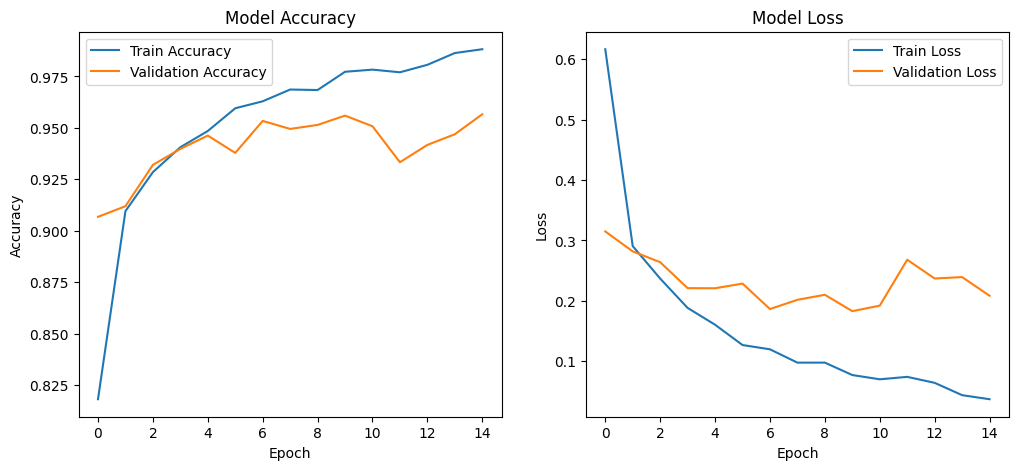

In [18]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

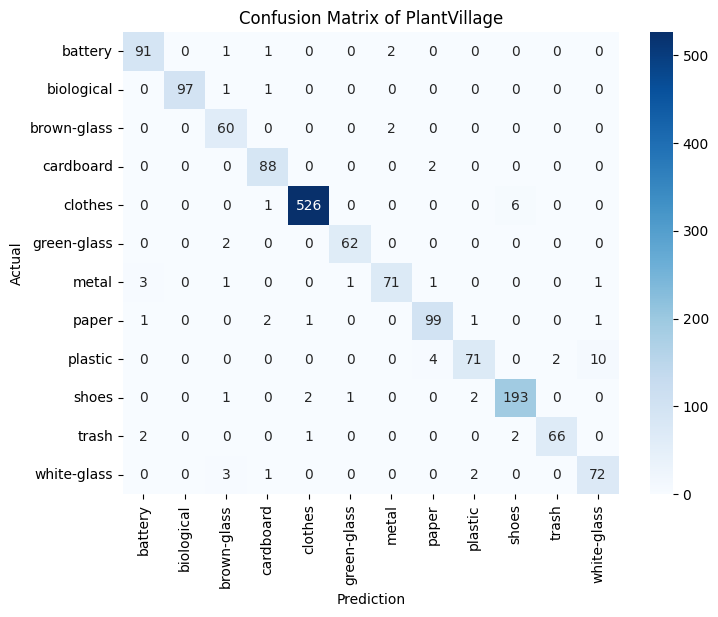

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix of PlantVillage')
plt.show()

In [20]:
train_acc_best = history.history['accuracy'][best_epoch_acc]

print("     FINAL PERFORMANCE      ")
print(f"Training Accuracy   : {train_acc_best * 100:.2f}%")
print(f"Validation Accuracy : {val_acc_max * 100:.2f}%")
print(f"Test Accuracy       : {accuracy * 100:.2f}%")

     FINAL PERFORMANCE      
Training Accuracy   : 98.82%
Validation Accuracy : 95.66%
Test Accuracy       : 95.84%


## Konversi Model

In [21]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS, 
    tf.lite.OpsSet.SELECT_TF_OPS   
]
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpwi_g6k1_/assets


INFO:tensorflow:Assets written to: /tmp/tmpwi_g6k1_/assets


Saved artifact at '/tmp/tmpwi_g6k1_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_159')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  134168095948624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095945936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095945168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095943824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095946704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095944016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095947088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095944784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095948240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095945360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095

W0000 00:00:1772316656.779218      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772316656.779262      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772316656.927491      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [22]:
base_dir = 'submission'
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.makedirs(f'{base_dir}/tflite', exist_ok=True)
os.makedirs(f'{base_dir}/tfjs_model', exist_ok=True)

tflite_path = f'{base_dir}/tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
    
with open(f'{base_dir}/tflite/label.txt', 'w') as f:
    for s in class_names:
        f.write(s + '\n')

total_size_bytes = os.path.getsize(tflite_path)
custom_shard_size = int(total_size_bytes / 4.2) 

tfjs.converters.save_keras_model(
    model, 
    f'{base_dir}/tfjs_model', 
    weight_shard_size_bytes=custom_shard_size 
)

model.export(f'{base_dir}/saved_model')

shutil.make_archive('submission_fix', 'zip', base_dir)

print("✅ Success!!!")

failed to lookup keras version from the file,
    this is likely a weight only file
INFO:tensorflow:Assets written to: submission/saved_model/assets


INFO:tensorflow:Assets written to: submission/saved_model/assets


Saved artifact at 'submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_159')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  134168095934224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095938256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095939024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095938448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095948624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095945936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095945168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095943824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095946704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134168095944016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134

## Inference (Optional)

In [39]:
image_url = "https://tse4.mm.bing.net/th/id/OIP.MlGeZeFvhgi8a0Q1tr5IsgHaHa?rs=1&pid=ImgDetMain&o=7&rm=3"

In [40]:
label_path = "submission/tflite/label.txt"
with open(label_path, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

In [41]:
response = requests.get(image_url)
img = Image.open(BytesIO(response.content)).convert('RGB')

In [42]:
interpreter = tf.lite.Interpreter(model_path="submission/tflite/model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [43]:
img_resized = img.resize((224, 224))
img_array = np.array(img_resized).astype(np.float32)

input_data = (img_array / 127.5) - 1.0
input_data = np.expand_dims(input_data, axis=0)

In [44]:
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

In [45]:
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_idx = np.argmax(output_data[0])
confidence = output_data[0][predicted_idx]

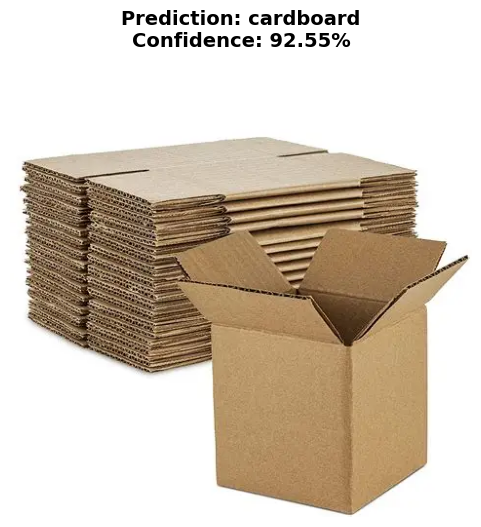

In [46]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {class_names[predicted_idx]}\nConfidence: {confidence*100:.2f}%", 
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()